<a href="https://colab.research.google.com/github/asommula-code/PRODIGY_ML_01/blob/main/PRODIGY_ML_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost -q

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from xgboost import XGBRegressor

import pickle

import warnings
warnings.filterwarnings("ignore")

In [ ]:
uploaded = files.upload()

Saving test.csv to test.csv
Saving train.csv to train.csv


In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train Shape:", train.shape)
print("Test Shape :", test.shape)

train.head()

Train Shape: (1460, 81)
Test Shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
missing = train.isnull().sum()

missing = missing[
    missing > 0
].sort_values(
    ascending=False
)

print(missing.head(20))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


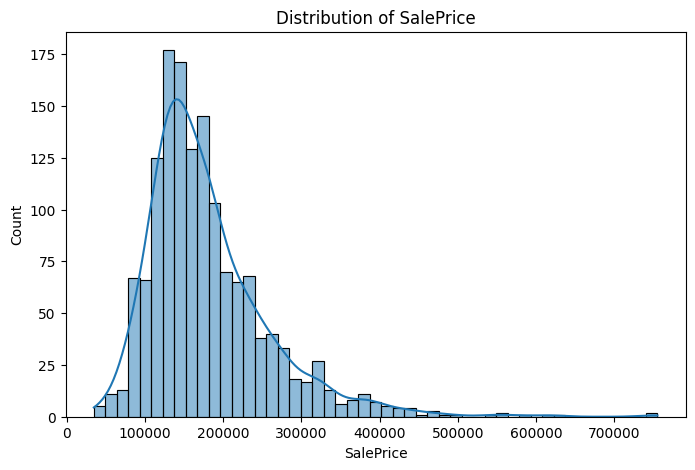

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    train["SalePrice"],
    kde=True
)

plt.title(
    "Distribution of SalePrice"
)

plt.show()

In [ ]:
corr = train.corr(
    numeric_only=True
)

top_corr = corr[
    "SalePrice"
].sort_values(
    ascending=False
)

print(top_corr.head(15))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


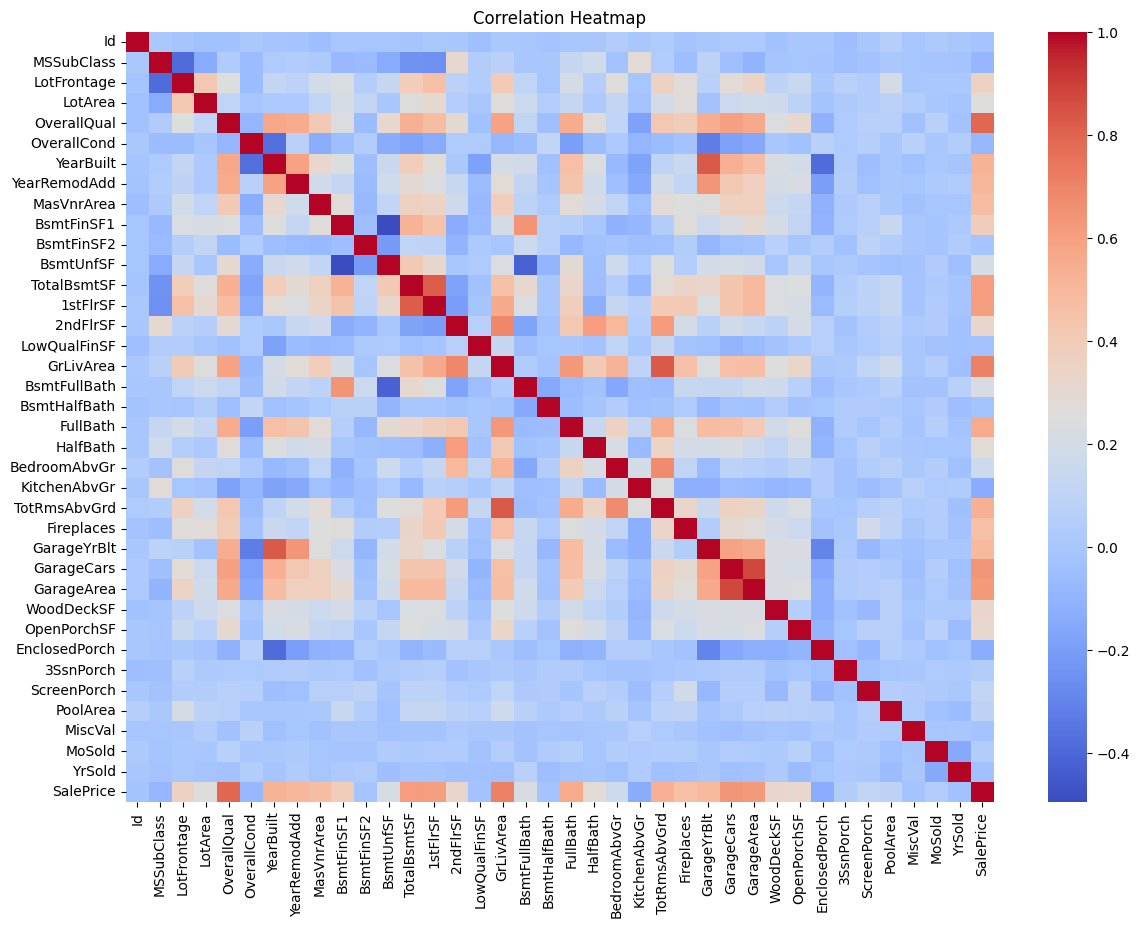

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

In [ ]:
required_features = [
    "GrLivArea",
    "BedroomAbvGr",
    "FullBath"
]

X = train[
    required_features
]

y = train[
    "SalePrice"
]

In [ ]:
X = X.fillna(
    X.mean()
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

print(
    "Linear Regression Trained Successfully"
)

Linear Regression Trained Successfully


In [ ]:
linear_predictions = linear_model.predict(
    X_test
)

linear_predictions[:5]

array([113410.67255298, 305081.87775899, 135904.78562983, 205424.67564124,
       227502.68349004])

In [ ]:
mae = mean_absolute_error(
    y_test,
    linear_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

r2 = r2_score(
    y_test,
    linear_predictions
)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2  :", round(r2,4))

MAE : 35788.06
RMSE: 52975.72
R2  : 0.6341


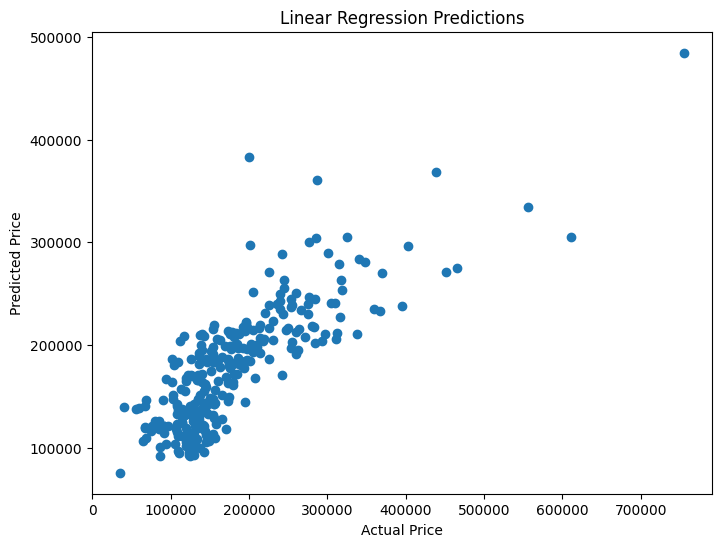

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    linear_predictions
)

plt.xlabel(
    "Actual Price"
)

plt.ylabel(
    "Predicted Price"
)

plt.title(
    "Linear Regression Predictions"
)

plt.show()

In [ ]:
sample_house = pd.DataFrame({
    "GrLivArea":[2000],
    "BedroomAbvGr":[4],
    "FullBath":[3]
})

predicted_price = linear_model.predict(
    sample_house
)

print(
    "Predicted Price:",
    round(predicted_price[0],2)
)

Predicted Price: 243736.67


In [ ]:
X_full = train.drop(
    ["SalePrice","Id"],
    axis=1
)

y_full = train[
    "SalePrice"
]

X_submission = test.drop(
    ["Id"],
    axis=1
)

In [ ]:
numeric_features = X_full.select_dtypes(
    include=["int64","float64"]
).columns

categorical_features = X_full.select_dtypes(
    include=["object"]
).columns

print(
    "Numerical:",
    len(numeric_features)
)

print(
    "Categorical:",
    len(categorical_features)
)

Numerical: 36
Categorical: 43


In [ ]:
numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_transformer,
        numeric_features
    ),
    (
        "cat",
        categorical_transformer,
        categorical_features
    )
])

In [ ]:
X_train_full, X_valid_full, y_train_full, y_valid_full = train_test_split(
    X_full,
    y_full,
    test_size=0.20,
    random_state=42
)

In [ ]:
models = {

    "Linear Regression":
    LinearRegression(),

    "Ridge":
    Ridge(alpha=1.0),

    "Lasso":
    Lasso(alpha=0.001),

    "Random Forest":
    RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    "XGBoost":
    XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

In [ ]:
results = []

best_model = None
best_name = None
best_r2 = -999

for name, model in models.items():

    pipeline = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            model
        )
    ])

    pipeline.fit(
        X_train_full,
        y_train_full
    )

    preds = pipeline.predict(
        X_valid_full
    )

    mae = mean_absolute_error(
        y_valid_full,
        preds
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_valid_full,
            preds
        )
    )

    r2 = r2_score(
        y_valid_full,
        preds
    )

    results.append([
        name,
        mae,
        rmse,
        r2
    ])

    if r2 > best_r2:
        best_r2 = r2
        best_model = pipeline
        best_name = name

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

results_df

,Model,MAE,RMSE,R2 Score
4,XGBoost,15207.207031,24470.394194,0.921933
2,Lasso,18001.679876,28313.704328,0.895485
3,Random Forest,17360.377728,28398.152813,0.894860
0,Linear Regression,18287.698623,29473.873055,0.886744
1,Ridge,19004.408494,29841.823697,0.883899


In [ ]:
print(
    "Best Model:",
    best_name
)

print(
    "Best R2:",
    round(best_r2,4)
)

Best Model: XGBoost
Best R2: 0.9219


In [ ]:
with open(
    "best_house_price_model.pkl",
    "wb"
) as f:

    pickle.dump(
        best_model,
        f
    )

print(
    "Model Saved Successfully"
)

Model Saved Successfully


In [ ]:
submission_predictions = best_model.predict(
    X_submission
)

submission = pd.DataFrame({

    "Id": test["Id"],

    "SalePrice":
    submission_predictions
})

submission.to_csv(
    "submission.csv",
    index=False
)

submission.head()

,Id,SalePrice
0,1461,128956.531250
1,1462,156364.640625
2,1463,183363.796875
3,1464,194122.703125
4,1465,196827.765625


In [ ]:
files.download(
    "submission.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>